In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE, RFECV
from sklearn.datasets import make_classification
import seaborn as sns

parkinson = pd.read_csv('downloads/Parkinsons.csv')

pdf = pd.read_csv('downloads/Parkinsons.csv')
pdf['sex'] = pdf['sex'].astype(int)

In [17]:
X = pdf.drop('sex', axis=1)
y = pdf['sex']
feature_names = X.columns

# split data
X_tr, X_te, y_tr, y_te = train_test_split(X, y, 
                                          test_size = 0.2, 
                                          random_state = 25)
# create scaler
scaler = StandardScaler()
# transform test and training data
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

# create model & fit it
log_m = LogisticRegression()
log_m.fit(X_tr_sc, y_tr)
print(f"Intercept: {log_m.intercept_}")
print(f"Coefficients: {log_m.coef_}")

# make predictions
y_pred = log_m.predict(X_te_sc)

Intercept: [-1.74054216]
Coefficients: [[ 0.75917186  0.14119751  0.08728075  0.78562116 -1.26046893  1.48290138
  -7.52501695  2.25692422 -1.1980413   2.24603339  0.71757399  0.18284125
  -0.97053478  1.4019572  -0.87802055 -0.96992047  3.43133304 -0.75597547
  -0.20888416  0.49959769 -0.2717445 ]]


Accuracy Score: 0.908936170212766
Confusion Matrix: [[753  46]
 [ 61 315]]
Class Report:               precision    recall  f1-score   support

           0       0.93      0.94      0.93       799
           1       0.87      0.84      0.85       376

    accuracy                           0.91      1175
   macro avg       0.90      0.89      0.89      1175
weighted avg       0.91      0.91      0.91      1175



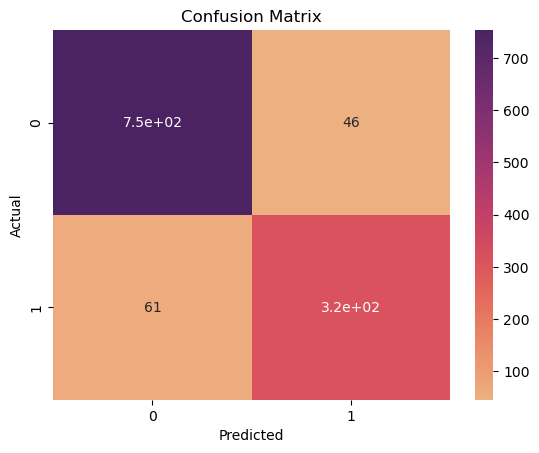

In [19]:
# evaluate model
log_m_acc = accuracy_score(y_te, y_pred)
log_m_cfm = confusion_matrix(y_te, y_pred)
log_m_cr = classification_report(y_te, y_pred)

print(f"Accuracy Score: {log_m_acc}")
print(f"Confusion Matrix: {log_m_cfm}")
print(f"Class Report: {log_m_cr}")

sns.heatmap(log_m_cfm, annot=True, cmap="flare", xticklabels=True, yticklabels=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [21]:
# Recursive Feature Elimination 
log_m = LogisticRegression(max_iter=5000)

# Manual
rfe = RFE(estimator = log_m, n_features_to_select = 10)
rfe.fit(X_tr, y_tr)
y_pred = rfe.predict(X_te)
print(f"Selected Features: {rfe.support_}")
print(f"Test Accuracy:", accuracy_score(y_te, y_pred))

Selected Features: [False False False False False  True False False  True  True False False
  True False  True  True  True False  True  True  True]
Test Accuracy: 0.7106382978723405


In [ ]:
# Recursive Feature Elimination Loop
X_tr = pd.DataFrame(X_tr, columns=feature_names)
X_te = pd.DataFrame(X_te, columns=feature_names)

best_acc = 0
best_n = None
best_features = None

for n in range(1, 21):
    try:
        log_m = LogisticRegression(max_iter=5000, solver='lbfgs')
        
        rfe = RFE(estimator = log_m, n_features_to_select = n)
        rfe.fit(X_tr, y_tr)

        y_pred = rfe.predict(X_te)
        acc = accuracy_score(y_te, y_pred)

        # get selected feature names
        selected_features = X_tr.columns[rfe.support_].tolist()

        print(f"\n=== {n} Features Selected ===")
        print(f"Selected Features: {rfe.support_}")
        print(f"Test Accuracy: {acc:.4f}")

        # track best
        if acc > best_acc:
            best_acc = acc
            best_n = n
            best_features = selected_features
            
        print(f"\nBest Accuracy: {best_acc:.4f} with {best_n} features")
        
    except ValueError as e:
        print(f"Skipping {n} features due to error: {e}")

print(f"\n=== Best Result ===")
print(f"Best Accuracy: {best_acc:.4f} with {best_n} features")
print(f"Best Feature Set: {best_features}")

In [23]:
# Recursive Feature Elimination with Cross Validation
log_m = LogisticRegression(max_iter=5000)
cv = StratifiedKFold(5)
rfecv = RFECV(estimator = log_m, 
              step = 1, cv = cv,
              scoring = 'accuracy',
              n_jobs = 2)
rfecv.fit(X,y)

print(f"Optimal Number of Features: {rfecv.n_features_}")

Optimal Number of Features: 2


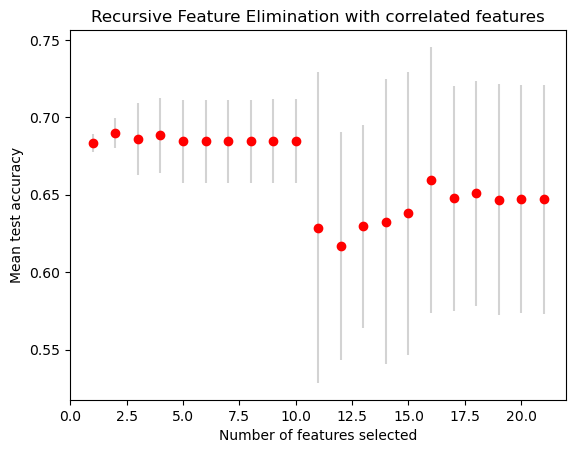

In [25]:
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(range(1, len(rfecv.cv_results_['mean_test_score'])+1),
             rfecv.cv_results_['mean_test_score'],
             yerr=rfecv.cv_results_['std_test_score'],
            fmt='o', color='red', ecolor='lightgray')
plt.title("Recursive Feature Elimination with correlated features")
plt.show()

In [27]:
## Log Regression: Sex Classification by Optimal # of Features (2)

# RFE with n = Optimal No.
log_m = LogisticRegression(max_iter=5000)
rfe = RFE(estimator = log_m, n_features_to_select = 2)
rfe.fit(X_tr, y_tr)
selected_features = X_tr.columns[rfe.support_].tolist()

y_pred = rfe.predict(X_te)
print(f"Selected Features: {rfe.support_}")
print(f"Selected Feature Set: {selected_features}")

Selected Features: [False False False False False False False False False False False False
 False False False False  True False  True False False]
Selected Feature Set: ['nhr', 'rpde']


In [31]:
X = pdf[['nhr', 'rpde']]
y = pdf['sex']
feature_names = X.columns

X_tr, X_te, y_tr, y_te = train_test_split(X, y, 
                                          test_size = 0.2, 
                                          random_state = 25)

# create scaler
scaler = StandardScaler()
# transform test and training data
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

# create model & fit it
lrom = LogisticRegression()
lrom.fit(X_tr_sc, y_tr)
print(f"Intercept: {lrom.intercept_}")
print(f"Coefficients: {lrom.coef_}")

# make predictions
y_pred = lrom.predict(X_te_sc)

Intercept: [-0.80115503]
Coefficients: [[ 0.87817278 -0.6949279 ]]


Accuracy Score: 0.7157446808510638
Precision Score: 0.6875
Recall Score: 0.2047872340425532
F1 Score: 0.3155737704918033
Confusion Matrix: [[764  35]
 [299  77]]
Class Report:               precision    recall  f1-score   support

           0       0.72      0.96      0.82       799
           1       0.69      0.20      0.32       376

    accuracy                           0.72      1175
   macro avg       0.70      0.58      0.57      1175
weighted avg       0.71      0.72      0.66      1175



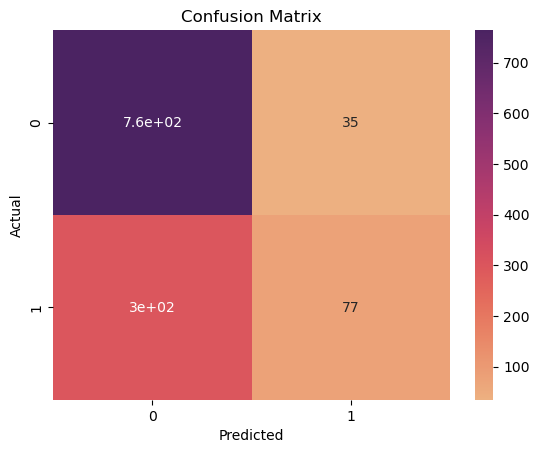

In [33]:
# evaluate model
lrom_acc = accuracy_score(y_te, y_pred)
lrom_cfm = confusion_matrix(y_te, y_pred)
lrom_cr = classification_report(y_te, y_pred)
lrom_pr = precision_score(y_te, y_pred)
lrom_re = recall_score(y_te, y_pred)
lrom_f1 = f1_score(y_te, y_pred)

print(f"Accuracy Score: {lrom_acc}")
print(f"Precision Score: {lrom_pr}")
print(f"Recall Score: {lrom_re}")
print(f"F1 Score: {lrom_f1}")
print(f"Confusion Matrix: {lrom_cfm}")
print(f"Class Report: {lrom_cr}")

sns.heatmap(lrom_cfm, annot=True, cmap="flare", xticklabels=True, yticklabels=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

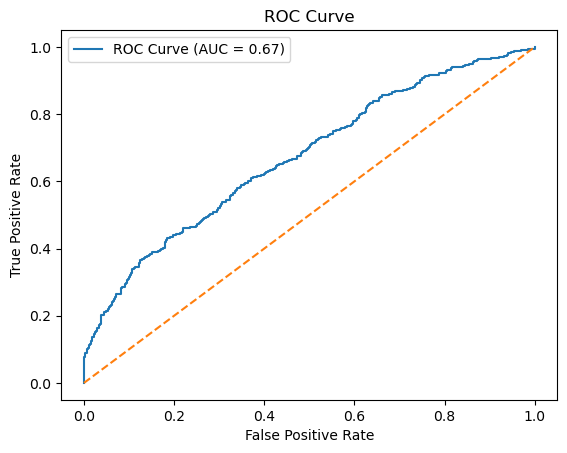

In [35]:
y_prob = lrom.predict_proba(X_te.values)[:, 1]
fpr, tpr, thresholds = roc_curve(y_te, y_prob)
roc_auc = roc_auc_score(y_te, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()